# Exploración y Análisis de ERA5 · Agregación de series temporales de precipitación (`tp`) · Chile 2000-2025

Proyecto de análisis que parte de la **precipitación total diaria** (`tp_suma`, mm/día) generada en
`era5_extraccion_diario.ipynb` y la agrega en el **tiempo** (mensual, estacional, anual, año hidrológico),
calcula **índices de extremos**, **climatologías y anomalías**, y la agrega en el **espacio** (zonas de Chile y ciudades).

| Sección | Contenido |
|---|---|
| 1 | Configuración: imports, parámetros y cluster Dask |
| 2 | Lectura, validación y máscara de Chile |
| 3 | Agregación temporal: mensual, estacional, anual, año hidrológico |
| 4 | Índices de precipitación (tipo ETCCDI) |
| 5 | Climatologías y anomalías |
| 6 | Agregación espacial: zonas y ciudades |
| 7 | Cómputo único y guardado en NetCDF |
| 8 | Validación (conservación de masa) |
| 9 | Visualizaciones |
| 10 | Tendencias |
| 11 | Tabla resumen y exportación a CSV |

**Reglas de agregación**
- La precipitación se **suma** (mm/día → mm/mes, mm/año); nunca se promedia para pasar de un período a otro.
- Solo se conservan períodos **completos** (todos sus días presentes). Un mes con días faltantes subestimaría el total.
- Las secciones 2-6 solo construyen grafos perezosos de Dask; el cómputo ocurre en la sección 7 (un cómputo por producto).

## 1. Configuración inicial

### Imports
Se importan todos los paquetes al inicio, ordenados alfabéticamente por módulo.

Requisitos: `xarray dask distributed netCDF4 scipy matplotlib geopandas shapely` y, muy recomendado, **`flox`** (hace que los `groupby` sobre arreglos Dask sean mucho más rápidos):
`pip install flox`.

In [1]:
import dask
from dask.distributed import Client, get_client
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy.special import stdtr
import shapely
import xarray as xr

### Parámetros

Todo lo ajustable está aquí. La ruta base puede sobrescribirse con la variable de entorno `ERA5_DIR`.
El **año hidrológico** por defecto va de abril a marzo (hemisferio sur: la temporada de lluvias en Chile central queda en un solo año).

In [2]:
# --- Rutas -------------------------------------------------------------------
DIR_BASE = Path(os.environ.get('ERA5_DIR', r'D:\Documents\Proyectos\era5'))
ARCHIVO_TP = DIR_BASE / 'diario_era5_chile' / 'tp_diario_2000_2025.nc'
DIR_SALIDA = DIR_BASE / 'agregados_tp'
DIR_FIGURAS = DIR_SALIDA / 'figuras'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

# --- Datos y período ---------------------------------------------------------
VARIABLE = 'tp_suma'            # mm/día (salida de era5_extraccion_diario.ipynb)
ANIO_INI, ANIO_FIN = 2000, 2025

# --- Umbrales de los índices --------------------------------------------------
UMBRAL_DIA_HUMEDO = 1.0         # mm/día: día "húmedo" (R1mm, SDII, CDD)
UMBRAL_R10, UMBRAL_R20 = 10.0, 20.0
PERCENTIL_EXTREMO = 0.95        # percentil de días húmedos para R95pTOT
CLIM_MINIMA_PCT = 1.0           # mm/mes: bajo esta climatología no se calcula anomalía en %

# --- Calendario ----------------------------------------------------------------
MES_INICIO_ANIO_HIDRO = 4       # 4 = abril  (año hidrológico abril-marzo)
MESES_PD = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
FREQ_HIDRO = f'YS-{MESES_PD[MES_INICIO_ANIO_HIDRO - 1]}'
ESTACION_POR_MES_INICIO = {12: 'DJF', 3: 'MAM', 6: 'JJA', 9: 'SON'}
ORDEN_ESTACIONES = ['DJF', 'MAM', 'JJA', 'SON']
NOMBRES_MES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# --- Espacio ---------------------------------------------------------------------
USAR_MASCARA_CHILE = True       # True: solo celdas cuyo centro cae dentro de Chile
ARCHIVO_REGIONES = Path(os.environ.get(
    'ERA5_REGIONES',
    r'D:\Documents\adm_boundaries_overture\chile_limites_administrativos\chile_region.geojson'))
DIBUJAR_LIMITES_REGIONALES = True   # True: dibuja los límites de las 16 regiones; False: solo el contorno del país

# Zonas por banda de latitud (norte, sur), en °S negativos
ZONAS = {
    'Norte Grande': (-17.0, -26.0),
    'Norte Chico':  (-26.0, -32.0),
    'Centro':       (-32.0, -37.0),
    'Sur':          (-37.0, -43.0),
    'Austral':      (-43.0, -56.5),
}
NOMBRE_TOTAL = 'Chile'
ZONA_HEATMAP = 'Centro'

# Ciudades (lat, lon): se toma la celda ERA5 más cercana
CIUDADES = {
    'Arica':        (-18.48, -70.32),
    'Antofagasta':  (-23.65, -70.40),
    'La Serena':    (-29.90, -71.25),
    'Santiago':     (-33.45, -70.67),
    'Concepción':   (-36.83, -73.05),
    'Temuco':       (-38.74, -72.60),
    'Valdivia':     (-39.81, -73.25),
    'Puerto Montt': (-41.47, -72.94),
    'Punta Arenas': (-53.16, -70.91),
}

### Cluster de Dask

Cluster local en proceso con pocos hilos (los datos ya están en disco, no hay red de por medio).
Se cierra cualquier cluster previo por si la celda se vuelve a ejecutar. Docs: [`dask.distributed.Client`](https://distributed.dask.org/en/stable/client.html).

In [ ]:
try:
    get_client().close()
    print('Cluster previo detectado y cerrado.')
except ValueError:
    pass

client = Client(processes=False, n_workers=1, threads_per_worker=8)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://192.168.1.2:8787/status,
Dashboard: http://192.168.1.2:8787/status,Workers: 1
Total threads: 8,Total memory: 15.30 GiB
Status: running,Using processes: False
Comm: inproc://192.168.1.2/11288/1,Workers: 0
Dashboard: http://192.168.1.2:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: inproc://192.168.1.2/11288/4,Total threads: 8
Dashboard: http://192.168.1.2:64099/status,Memory: 15.30 GiB
Nanny: None,


c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divi

### Estilo de gráficos

Ejes sobrios, grilla tenue, un solo eje Y por gráfico (las magnitudes muy distintas entre zonas se muestran en paneles separados, no en doble eje).
Magnitudes → escala secuencial de un solo tono; anomalías → par divergente marrón/verde-azulado con centro neutro.

In [4]:
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
})
COLOR_BARRA = '#2C6E9B'      # magnitud
COLOR_POS, COLOR_NEG = '#1B7F79', '#A6611A'   # anomalía húmeda / seca (extremos de BrBG)
COLOR_TEXTO = '#444444'


def guardar_figura(fig, nombre):
    fig.savefig(DIR_FIGURAS / f'{nombre}.png')

## 2. Lectura, validación y máscara de Chile

### Apertura perezosa
El archivo se abre con **un solo bloque en el tiempo** y bloques de latitud: así los percentiles, las rachas secas y los `resample`
trabajan sobre la serie completa de cada celda sin tener que reagrupar. Docs: [`xarray.open_dataset`](https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html).

In [5]:
ds = xr.open_dataset(ARCHIVO_TP, chunks={'time': -1, 'latitude': 32, 'longitude': -1})
tp_raw = ds[VARIABLE]

print(ARCHIVO_TP)
print(f'Variable: {VARIABLE} | unidades: {tp_raw.attrs.get("units")} | dims: {dict(tp_raw.sizes)}')
print(f'Tiempo: {str(tp_raw.time.values[0])[:10]} -> {str(tp_raw.time.values[-1])[:10]}')
print(f'Latitud: {float(tp_raw.latitude.min()):.2f}..{float(tp_raw.latitude.max()):.2f} | '
      f'Longitud: {float(tp_raw.longitude.min()):.2f}..{float(tp_raw.longitude.max()):.2f}')
print(f'Tamaño en memoria si se cargara: {tp_raw.nbytes / 1e6:.0f} MB | chunks: {tp_raw.data.chunksize}')

D:\Documents\Proyectos\era5\diario_era5_chile\tp_diario_2000_2025.nc
Variable: tp_suma | unidades: mm day-1 | dims: {'time': 9497, 'latitude': 157, 'longitude': 45}
Tiempo: 2000-01-01 -> 2025-12-31
Latitud: -56.00..-17.00 | Longitud: -77.00..-66.00
Tamaño en memoria si se cargara: 268 MB | chunks: (9497, 32, 45)


C:\Users\Javiera\AppData\Local\Temp\ipykernel_11288\604962252.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 32. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(ARCHIVO_TP, chunks={'time': -1, 'latitude': 32, 'longitude': -1})


### Chequeos de calidad

Se verifica: días faltantes o fuera del período, valores negativos y celdas con NaN.
Los días faltantes no se rellenan: los períodos que los contienen se descartan en la sección 3.
Docs: [`pandas.date_range`](https://pandas.pydata.org/docs/reference/api/pandas.date_range.html), [`dask.compute`](https://docs.dask.org/en/stable/api.html#dask.compute).

In [6]:
tiempos = pd.DatetimeIndex(tp_raw.time.values)
esperados = pd.date_range(f'{ANIO_INI}-01-01', f'{ANIO_FIN}-12-31', freq='D')
faltan = esperados.difference(tiempos)
sobran = tiempos.difference(esperados)
assert tiempos.is_monotonic_increasing and not tiempos.has_duplicates, 'Eje de tiempo desordenado o con duplicados'

minimo, maximo, n_nan = dask.compute(tp_raw.min(), tp_raw.max(), tp_raw.isnull().sum())
print(f'Días esperados: {len(esperados)} | presentes: {len(tiempos)} | faltan: {len(faltan)} | fuera de período: {len(sobran)}')
if len(faltan):
    print('  Primeros faltantes:', [d.strftime('%Y-%m-%d') for d in faltan[:5]])
print(f'Mínimo: {float(minimo):.3f} mm/día | máximo: {float(maximo):.1f} mm/día | valores NaN: {int(n_nan)}')
if float(minimo) < 0:
    print('AVISO: hay valores negativos.')

Días esperados: 9497 | presentes: 9497 | faltan: 0 | fuera de período: 0
Mínimo: 0.000 mm/día | máximo: 219.5 mm/día | valores NaN: 0


### Límites de Chile: máscara y contorno para los mapas

ERA5 entrega la caja completa (océano + Argentina). Se usa el GeoJSON de regiones (`chile_region.geojson`, Overture Maps: 16 regiones terrestres, EPSG:4326) para:

1. **Enmascarar** las celdas cuyo centro cae fuera del país: `shapely.intersects_xy` prueba todos los centros de celda contra el polígono, en una sola llamada vectorizada.
2. **Dibujar el contorno** (y, opcionalmente, los límites regionales) sobre cada mapa.

Antes se recorta la geometría a la caja de ERA5 con [`GeoSeries.clip_by_rect`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.clip_by_rect.html)
(deja fuera Isla de Pascua y Juan Fernández, que no están en la grilla) y para dibujar se simplifica con [`simplify`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.simplify.html)
(el archivo tiene ~20 MB de costa muy detallada; a 0,25° no se ve la diferencia).
Lectura: [`geopandas.read_file`](https://geopandas.org/en/stable/docs/reference/api/geopandas.read_file.html), máscara: [`shapely.intersects_xy`](https://shapely.readthedocs.io/en/stable/reference/shapely.intersects_xy.html).

`tp_raw` (sin máscara) se conserva para las **ciudades costeras**, cuya celda más cercana puede caer en el mar.

In [7]:
mascara_chile = None
contorno = None   # líneas para dibujar sobre los mapas (GeoSeries); None = no dibujar

if USAR_MASCARA_CHILE:
    try:
        regiones = gpd.read_file(ARCHIVO_REGIONES).to_crs('EPSG:4326')
        paso = 0.25   # se amplía la caja medio píxel para no perder celdas de borde
        x0, x1 = float(tp_raw.longitude.min()) - paso, float(tp_raw.longitude.max()) + paso
        y0, y1 = float(tp_raw.latitude.min()) - paso, float(tp_raw.latitude.max()) + paso

        # Recorte a la caja de ERA5 y descarte de regiones que quedan fuera (p. ej. Isla de Pascua)
        geoms = regiones.geometry.clip_by_rect(x0, y0, x1, y1)
        regiones_caja = regiones.assign(geometry=geoms)[~geoms.is_empty].reset_index(drop=True)
        pais = regiones_caja.geometry.union_all()
        shapely.prepare(pais)

        # ¿el centro de cada celda cae dentro (o en el borde) del país?
        lon2d, lat2d = np.meshgrid(tp_raw.longitude.values, tp_raw.latitude.values)
        dentro = shapely.intersects_xy(pais, lon2d, lat2d)
        mascara_chile = xr.DataArray(dentro, dims=('latitude', 'longitude'),
                                     coords={'latitude': tp_raw.latitude, 'longitude': tp_raw.longitude})

        # Geometría liviana para los mapas
        if DIBUJAR_LIMITES_REGIONALES:
            contorno = regiones_caja.geometry.simplify(0.005).boundary
        else:
            contorno = gpd.GeoSeries([shapely.simplify(pais, 0.005).boundary], crs='EPSG:4326')
        print(f'Regiones leídas: {len(regiones)} | dentro de la caja ERA5: {len(regiones_caja)}')
    except Exception as exc:   # archivo ausente, CRS inválido, etc.
        print(f'AVISO: no se pudo construir la máscara desde {ARCHIVO_REGIONES} ({exc!r}). Se usa toda la caja ERA5.')

if mascara_chile is None:
    mascara_chile = xr.ones_like(tp_raw.isel(time=0, drop=True), dtype=bool)

print(f'Celdas dentro de Chile: {int(mascara_chile.sum())} de {mascara_chile.size}')

tp = tp_raw.where(mascara_chile)   # perezoso
tp.name = 'tp'

c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Regiones leídas: 16 | dentro de la caja ERA5: 16
Celdas dentro de Chile: 1254 de 7065


## 3. Agregación temporal

### Funciones auxiliares

- `bins_completos(tiempos, freq)`: devuelve las etiquetas de los períodos cuyo número de días observados es igual al esperado por calendario.
  Así se descartan el primer/último período parcial (p. ej. el `DJF` que empieza en dic-1999) y cualquier período con días faltantes.
- `remuestrear(da, freq, como)`: suma (o máximo) por período con [`DataArray.resample`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.resample.html),
  con `min_count=1` para que las celdas enmascaradas sigan siendo NaN en vez de 0, y conservando solo períodos completos.

In [8]:
def bins_completos(tiempos, freq):
    """Etiquetas (inicio de período) de los períodos de `freq` con todos sus días presentes."""
    obs = pd.Series(1, index=pd.DatetimeIndex(tiempos)).resample(freq).sum()
    ultimo_dia = obs.index[-1] + pd.tseries.frequencies.to_offset(freq) - pd.Timedelta(days=1)
    esperado = pd.Series(1, index=pd.date_range(obs.index[0], ultimo_dia)).resample(freq).sum()
    return obs.index[obs.values == esperado.reindex(obs.index).values]


def remuestrear(da, freq, como='sum'):
    """Agrega `da` por período (`sum` o `max`) y deja solo los períodos completos."""
    r = da.resample(time=freq)
    out = r.sum(min_count=1) if como == 'sum' else r.max()
    return out.sel(time=bins_completos(da.time.values, freq))


def etiquetar_estacion(da):
    """Añade la coordenada `estacion` (DJF/MAM/JJA/SON) a una serie trimestral que empieza en dic/mar/jun/sep."""
    etiquetas = [ESTACION_POR_MES_INICIO[m] for m in da.time.dt.month.values]
    return da.assign_coords(estacion=('time', etiquetas))

### Totales mensuales, estacionales, anuales y por año hidrológico

| Producto | Frecuencia pandas | Etiqueta temporal |
|---|---|---|
| `tp_mes` | `MS` | primer día del mes |
| `tp_est` | `QS-DEC` (DJF, MAM, JJA, SON) | primer día del trimestre (DJF se etiqueta en diciembre) |
| `tp_anio` | `YS` | 1-ene del año |
| `tp_hidro` | `YS-APR` (según parámetro) | 1 del mes de inicio del año hidrológico |

In [9]:
tp_mes = remuestrear(tp, 'MS')
tp_est = etiquetar_estacion(remuestrear(tp, 'QS-DEC'))
tp_anio = remuestrear(tp, 'YS')
tp_hidro = remuestrear(tp, FREQ_HIDRO)

for nombre, obj in {'mensual': tp_mes, 'estacional': tp_est, 'anual': tp_anio, 'año hidrológico': tp_hidro}.items():
    t = pd.DatetimeIndex(obj.time.values)
    print(f'{nombre:16s} {len(t):4d} períodos completos | {t[0].strftime("%Y-%m-%d")} -> {t[-1].strftime("%Y-%m-%d")}')

meses_ok = pd.DatetimeIndex(tp_mes.time.values)
anios_ok = pd.DatetimeIndex(tp_anio.time.values)

mensual           312 períodos completos | 2000-01-01 -> 2025-12-01
estacional        103 períodos completos | 2000-03-01 -> 2025-09-01
anual              26 períodos completos | 2000-01-01 -> 2025-01-01
año hidrológico    25 períodos completos | 2000-04-01 -> 2024-04-01


## 4. Índices de precipitación (tipo ETCCDI)

Índices anuales calculados por celda, con los umbrales del bloque de parámetros:

| Variable | Índice | Definición |
|---|---|---|
| `r1mm` | R1mm | días con precipitación ≥ umbral de día húmedo |
| `sdii` | SDII | precipitación de días húmedos / número de días húmedos (mm/día húmedo) |
| `r10mm`, `r20mm` | R10mm, R20mm | días con ≥ 10 mm y ≥ 20 mm |
| `rx1day` | Rx1day | máximo anual de precipitación en 1 día |
| `rx5day` | Rx5day | máximo anual de precipitación acumulada en 5 días consecutivos (la ventana completa debe caer dentro del año) |
| `cdd` | CDD | racha máxima anual de días secos consecutivos (< umbral) |
| `r95ptot`, `r95p_pct` | R95pTOT | precipitación anual en días sobre el percentil 95 de los días húmedos (2000-2025) y su % del total anual |

Docs: [`DataArray.rolling`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.rolling.html),
[`DataArray.quantile`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.quantile.html),
[`xarray.apply_ufunc`](https://docs.xarray.dev/en/stable/generated/xarray.apply_ufunc.html).

In [10]:
valido = tp.notnull()
humedo = (tp >= UMBRAL_DIA_HUMEDO).where(valido)

r1mm = remuestrear(humedo, 'YS')
sdii = remuestrear(tp.where(tp >= UMBRAL_DIA_HUMEDO), 'YS') / r1mm.where(r1mm > 0)
r10mm = remuestrear((tp >= UMBRAL_R10).where(valido), 'YS')
r20mm = remuestrear((tp >= UMBRAL_R20).where(valido), 'YS')
rx1day = remuestrear(tp, 'YS', como='max')
# ventana de 5 días etiquetada en su último día; se exige que toda la ventana caiga dentro del mismo año
ventana5 = tp.rolling(time=5, min_periods=5).sum()
misma_ventana_anual = tp.time.dt.year == (tp.time - pd.Timedelta(days=4)).dt.year
rx5day = remuestrear(ventana5.where(misma_ventana_anual), 'YS', como='max')

# Percentil 95 de los días húmedos (referencia: todo el período). Requiere un único bloque en time.
p95_dia_humedo = tp.where(tp >= UMBRAL_DIA_HUMEDO).quantile(PERCENTIL_EXTREMO, dim='time', skipna=True).drop_vars('quantile')
extremo = tp.where(tp > p95_dia_humedo, 0.0).where(valido)
r95ptot = remuestrear(extremo, 'YS')
r95p_pct = 100 * r95ptot / tp_anio.where(tp_anio > 0)

### Racha máxima de días secos (CDD)

Para cada año se recorre la serie diaria: `cumsum` de días secos menos el valor acumulado en el último día húmedo da la longitud de la racha vigente;
su máximo es el CDD. La función trabaja sobre un eje de tiempo por año (no cruza el 31-dic → 1-ene) y se aplica bloque a bloque con `apply_ufunc(dask='parallelized')`.

In [11]:
def _racha_seca_max(seco):
    """seco: bool con el tiempo en el último eje. Devuelve la racha máxima de Trues."""
    acumulado = np.cumsum(seco, axis=-1)
    reinicio = np.maximum.accumulate(np.where(seco, 0, acumulado), axis=-1)
    return (acumulado - reinicio).max(axis=-1).astype('float32')


def racha_seca_anual(seco):
    def _por_anio(x):
        return xr.apply_ufunc(_racha_seca_max, x, input_core_dims=[['time']],
                              dask='parallelized', output_dtypes=[np.float32])
    out = seco.groupby('time.year').map(_por_anio)
    fechas = pd.to_datetime([f'{a}-01-01' for a in out.year.values])
    return out.assign_coords(year=fechas).rename(year='time')


seco = (tp < UMBRAL_DIA_HUMEDO).where(valido, False)
cdd = racha_seca_anual(seco).where(valido.any('time')).sel(time=anios_ok)

## 5. Climatologías y anomalías

- **Climatología** = media del período 2000-2025 de los totales (mensual por mes del año, estacional por estación, anual).
- **Anomalía absoluta** (mm), **relativa** (% de la climatología; solo donde la climatología ≥ `CLIM_MINIMA_PCT` mm/mes, para no dividir por casi cero en el desierto) y **estandarizada** (z = anomalía / desviación estándar).

Docs: [`DataArray.groupby`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.groupby.html).

In [12]:
# --- Mensual ---
g_mes = tp_mes.groupby('time.month')
clim_mes = g_mes.mean('time')
std_mes = g_mes.std('time')
anom_mes = g_mes - clim_mes
anom_mes_pct = 100 * (anom_mes.groupby('time.month') / clim_mes.where(clim_mes >= CLIM_MINIMA_PCT))
z_mes = anom_mes.groupby('time.month') / std_mes.where(std_mes > 0)

# --- Estacional ---
g_est = tp_est.groupby('estacion')
clim_est = g_est.mean('time').sel(estacion=ORDEN_ESTACIONES)
anom_est = g_est - g_est.mean('time')

# --- Anual y año hidrológico ---
clim_anio, std_anio = tp_anio.mean('time'), tp_anio.std('time')
cv_anio = 100 * std_anio / clim_anio.where(clim_anio > 0)
anom_anio = tp_anio - clim_anio
anom_anio_pct = 100 * anom_anio / clim_anio.where(clim_anio > 0)
z_anio = anom_anio / std_anio.where(std_anio > 0)

clim_hidro = tp_hidro.mean('time')
anom_hidro = tp_hidro - clim_hidro

## 6. Agregación espacial

### Zonas de Chile

Media **ponderada por área** (peso ∝ cos(latitud), porque las celdas de 0,25° se achican hacia los polos) dentro de cada banda de latitud,
más el total de Chile. Como se promedian totales por celda, la media areal de un total es el total de la media areal.
Docs: [`DataArray.weighted`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.weighted.html).

In [13]:
lat = tp.latitude
mascaras = [mascara_chile & (lat <= n) & (lat > s) for n, s in ZONAS.values()] + [mascara_chile]
mascaras_zonas = xr.concat(mascaras, dim=pd.Index(list(ZONAS) + [NOMBRE_TOTAL], name='zona'))
pesos_zonas = np.cos(np.deg2rad(lat)) * mascaras_zonas


def media_areal(da):
    """Media ponderada por área en cada zona (dimensión nueva `zona`)."""
    return da.weighted(pesos_zonas).mean(('latitude', 'longitude'))


print('Celdas por zona:', {z: int(mascaras_zonas.sel(zona=z).sum()) for z in mascaras_zonas.zona.values})

zonas_mes = media_areal(tp_mes)
zonas_est = media_areal(tp_est)
zonas_anio = media_areal(tp_anio)
zonas_hidro = media_areal(tp_hidro)

Celdas por zona: {'Norte Grande': 263, 'Norte Chico': 163, 'Centro': 143, 'Sur': 184, 'Austral': 501, 'Chile': 1254}


### Ciudades

Se toma la celda ERA5 más cercana a cada ciudad con selección puntual ([`DataArray.sel(method='nearest')`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.sel.html)),
sobre la serie **sin máscara** (`tp_raw`). Ojo: ERA5 tiene resolución de ~25 km, así que una celda no representa bien la orografía local (p. ej. valles precordilleranos).

In [14]:
lat_c = xr.DataArray([v[0] for v in CIUDADES.values()], dims='ciudad', coords={'ciudad': list(CIUDADES)})
lon_c = xr.DataArray([v[1] for v in CIUDADES.values()], dims='ciudad', coords={'ciudad': list(CIUDADES)})
tp_ciu = tp_raw.sel(latitude=lat_c, longitude=lon_c, method='nearest')

ciudades_mes = remuestrear(tp_ciu, 'MS')
ciudades_anio = remuestrear(tp_ciu, 'YS')

## 7. Cómputo y guardado

Se arman los `Dataset` de salida (todos siguen siendo perezosos) y recién aquí se ejecuta el cálculo: cada producto se computa y se escribe a NetCDF
por separado, y las series de zonas/ciudades se traen a memoria. Un grafo por producto (en vez de uno gigante que los una a todos) mantiene el uso de memoria bajo;
el costo es leer el diario del disco una vez por producto. Cada producto se calcula primero en memoria (`.compute()`, pesan decenas de MB) y después se escribe:
escribir directamente desde Dask con `to_netcdf` serializa la escritura y resultó unas 10 veces más lento.
Docs: [`Dataset.to_netcdf`](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.to_netcdf.html), [`dask.compute`](https://docs.dask.org/en/stable/api.html#dask.compute).

In [15]:
ATTRS_COMUNES = {
    'source': 'ERA5 (ARCO, Google Cloud) - tp diaria agregada en era5_agregacion_precipitacion.ipynb',
    'periodo': f'{ANIO_INI}-{ANIO_FIN}',
    'mascara_chile': str(bool(USAR_MASCARA_CHILE) and int(mascara_chile.sum()) < mascara_chile.size),
    'nota': 'Solo períodos completos; totales = suma de mm/día.',
}


def con_attrs(ds_, titulo, unidades=None):
    ds_.attrs = {'title': titulo, **ATTRS_COMUNES}
    if unidades:
        for v, u in unidades.items():
            ds_[v].attrs['units'] = u
    return ds_


ds_mensual = con_attrs(xr.Dataset({
    'tp_mes': tp_mes, 'anom_mm': anom_mes, 'anom_pct': anom_mes_pct, 'anom_z': z_mes,
    'dias_humedos': remuestrear(humedo, 'MS'), 'rx1day': remuestrear(tp, 'MS', como='max'),
}), 'Precipitación mensual, anomalías y días húmedos',
    {'tp_mes': 'mm', 'anom_mm': 'mm', 'anom_pct': '%', 'anom_z': '1', 'dias_humedos': 'días', 'rx1day': 'mm/día'})

ds_estacional = con_attrs(xr.Dataset({'tp_est': tp_est, 'anom_mm': anom_est}),
                          'Precipitación estacional (DJF, MAM, JJA, SON)', {'tp_est': 'mm', 'anom_mm': 'mm'})

ds_anual = con_attrs(xr.Dataset({
    'tp_anio': tp_anio, 'anom_mm': anom_anio, 'anom_pct': anom_anio_pct, 'anom_z': z_anio,
    'r1mm': r1mm, 'sdii': sdii, 'r10mm': r10mm, 'r20mm': r20mm,
    'rx1day': rx1day, 'rx5day': rx5day, 'cdd': cdd, 'r95ptot': r95ptot, 'r95p_pct': r95p_pct,
}), 'Precipitación anual, anomalías e índices de extremos',
    {'tp_anio': 'mm', 'anom_mm': 'mm', 'anom_pct': '%', 'anom_z': '1', 'r1mm': 'días', 'sdii': 'mm/día húmedo',
     'r10mm': 'días', 'r20mm': 'días', 'rx1day': 'mm/día', 'rx5day': 'mm/5 días', 'cdd': 'días',
     'r95ptot': 'mm', 'r95p_pct': '%'})

ds_hidro = con_attrs(xr.Dataset({'tp_hidro': tp_hidro, 'anom_mm': anom_hidro}),
                     f'Precipitación por año hidrológico (inicio: mes {MES_INICIO_ANIO_HIDRO})',
                     {'tp_hidro': 'mm', 'anom_mm': 'mm'})

ds_clim = con_attrs(xr.Dataset({
    'clim_mes': clim_mes, 'std_mes': std_mes, 'clim_est': clim_est,
    'clim_anio': clim_anio, 'std_anio': std_anio, 'cv_anio': cv_anio,
    'clim_hidro': clim_hidro, 'p95_dia_humedo': p95_dia_humedo,
}), f'Climatologías {ANIO_INI}-{ANIO_FIN}',
    {'clim_mes': 'mm/mes', 'std_mes': 'mm/mes', 'clim_est': 'mm/estación', 'clim_anio': 'mm/año',
     'std_anio': 'mm/año', 'cv_anio': '%', 'clim_hidro': 'mm/año hidrológico', 'p95_dia_humedo': 'mm/día'})

PRODUCTOS = {
    'tp_mensual': ds_mensual, 'tp_estacional': ds_estacional, 'tp_anual': ds_anual,
    'tp_hidrologico': ds_hidro, 'tp_climatologias': ds_clim,
}
SERIES = {
    'zonas_mensual': zonas_mes, 'zonas_estacional': zonas_est, 'zonas_anual': zonas_anio,
    'zonas_hidrologico': zonas_hidro, 'ciudades_mensual': ciudades_mes, 'ciudades_anual': ciudades_anio,
}


def escribir(ds_, nombre):
    ds_ = ds_.compute()   # cálculo en el cluster; el producto cabe en memoria (decenas de MB)
    enc = {v: {'zlib': True, 'complevel': 4, 'dtype': 'float32'} for v in ds_.data_vars}
    ds_.to_netcdf(DIR_SALIDA / f'{nombre}.nc', engine='netcdf4', encoding=enc)
    print(f'{nombre}.nc  {(DIR_SALIDA / (nombre + ".nc")).stat().st_size / 1e6:.1f} MB')

In [16]:
for nombre, producto in PRODUCTOS.items():
    escribir(producto, nombre)

# Series de zonas y ciudades: pequeñas, se traen a memoria
series = dict(zip(SERIES, dask.compute(*SERIES.values())))
print('Series en memoria:', list(series))

tp_mensual.nc  9.7 MB
tp_estacional.nc  1.2 MB
tp_anual.nc  1.6 MB
tp_hidrologico.nc  0.3 MB
tp_climatologias.nc  0.2 MB
Series en memoria: ['zonas_mensual', 'zonas_estacional', 'zonas_anual', 'zonas_hidrologico', 'ciudades_mensual', 'ciudades_anual']


### Relectura de los productos

Ahora los productos son pequeños comparados con el diario: se cargan en memoria y se cierra el archivo
([`xarray.load_dataset`](https://docs.xarray.dev/en/stable/generated/xarray.load_dataset.html)) para no bloquear la escritura si se re-ejecuta la sección 7 en Windows.

In [17]:
mensual, estacional, anual, hidro, clim = (xr.load_dataset(DIR_SALIDA / f'{n}.nc') for n in PRODUCTOS)
z_mes_s, z_est_s, z_anio_s, z_hid_s = (series[k] for k in ['zonas_mensual', 'zonas_estacional', 'zonas_anual', 'zonas_hidrologico'])
c_mes_s, c_anio_s = series['ciudades_mensual'], series['ciudades_anual']

print('Mensual  :', dict(mensual.sizes))
print('Anual    :', dict(anual.sizes), '| variables:', list(anual.data_vars))
print('Zonas    :', list(z_anio_s.zona.values))

Mensual  : {'time': 312, 'latitude': 157, 'longitude': 45}
Anual    : {'time': 26, 'latitude': 157, 'longitude': 45} | variables: ['tp_anio', 'anom_mm', 'anom_pct', 'anom_z', 'r1mm', 'sdii', 'r10mm', 'r20mm', 'rx1day', 'rx5day', 'cdd', 'r95ptot', 'r95p_pct']
Zonas    : ['Norte Grande', 'Norte Chico', 'Centro', 'Sur', 'Austral', 'Chile']


## 8. Validación

Comprobaciones de conservación y coherencia:
1. La suma de los 12 totales mensuales de cada año coincide con el total anual (en cada celda).
2. La suma de las cuatro estaciones consecutivas (DJF que empieza en dic Y-1, MAM, JJA, SON de Y) coincide con la suma de esos mismos 12 meses (dic Y-1 a nov Y).
3. La media areal de Chile queda entre los mínimos y máximos de las zonas.
4. Coherencia de índices: R10mm ≤ R1mm, Rx1day ≤ Rx5day ≤ total anual, CDD ≤ 366.

In [18]:
# 1) meses vs año (celda a celda)
suma_meses = mensual.tp_mes.resample(time='YS').sum(min_count=12)
comunes = suma_meses.time.to_index().intersection(anual.time.to_index())
assert len(comunes) > 0
dif = np.abs(suma_meses.sel(time=comunes) - anual.tp_anio.sel(time=comunes))
print(f'1) máx |Σ meses - año| = {float(dif.max()):.2e} mm  ({len(comunes)} años)')
assert float(dif.max()) < 1e-2

# 2) estaciones vs meses: DJF de dic(Y-1) + MAM + JJA + SON de Y  ==  dic(Y-1) ... nov(Y)
est = estacional.tp_est
t_est = est.time.to_index()
t_mes = mensual.tp_mes.time.to_index()
ok = 0
for anio in range(ANIO_INI + 1, ANIO_FIN + 1):
    t_ini = [pd.Timestamp(anio - 1, 12, 1), pd.Timestamp(anio, 3, 1), pd.Timestamp(anio, 6, 1), pd.Timestamp(anio, 9, 1)]
    t_12 = pd.date_range(pd.Timestamp(anio - 1, 12, 1), periods=12, freq='MS')
    if all(t in t_est for t in t_ini) and all(t in t_mes for t in t_12):
        s_est = est.sel(time=t_ini).sum('time')
        s_mes = mensual.tp_mes.sel(time=t_12).sum('time')
        assert float(np.abs(s_est - s_mes).max()) < 1e-2, f'Estaciones != meses en {anio}'
        ok += 1
print(f'2) estaciones vs meses verificadas en {ok} años')
assert ok > 0

# 3) coherencia espacial
chile = z_anio_s.sel(zona=NOMBRE_TOTAL)
zonas_solo = z_anio_s.sel(zona=list(ZONAS))
assert bool((chile <= zonas_solo.max('zona') + 1e-6).all()) and bool((chile >= zonas_solo.min('zona') - 1e-6).all())
print('3) la media de Chile queda dentro del rango de las zonas')

# 4) coherencia de índices (las celdas enmascaradas son NaN y se ignoran)
def menor_igual(a, b, tol=1e-3):
    return bool(((a <= b + tol) | a.isnull() | b.isnull()).all())


assert menor_igual(anual.r10mm, anual.r1mm) and menor_igual(anual.r20mm, anual.r10mm)
assert menor_igual(anual.rx1day, anual.rx5day) and menor_igual(anual.rx5day, anual.tp_anio)
assert float(anual.cdd.max()) <= 366
print('4) índices coherentes. Validación OK.')

1) máx |Σ meses - año| = 6.84e-03 mm  (26 años)
2) estaciones vs meses verificadas en 25 años
3) la media de Chile queda dentro del rango de las zonas
4) índices coherentes. Validación OK.


## 9. Visualizaciones

Helper de mapas: `pcolormesh` de la grilla sin proyección (cada celda ≈ 25 km) con el contorno de Chile / límites regionales encima (`contorno`, sección 2). Docs: [`matplotlib.axes.Axes.pcolormesh`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pcolormesh.html).

In [19]:
def mapa(da, ax, cmap, titulo, etiqueta, vmin=None, vmax=None):
    im = ax.pcolormesh(da.longitude, da.latitude, da.values, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    if contorno is not None:
        contorno.plot(ax=ax, color='#333333', linewidth=0.5)
        ax.set_ylabel('')   # geopandas pone su propia etiqueta de eje
    ax.set_xlim(float(da.longitude.min()) - 0.125, float(da.longitude.max()) + 0.125)
    ax.set_ylim(float(da.latitude.min()) - 0.125, float(da.latitude.max()) + 0.125)
    ax.set_aspect('equal')
    ax.set_title(titulo)
    ax.set_xlabel('Longitud (°)')
    ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=0.55, pad=0.03, label=etiqueta)
    return im

def p_alto(da, q=98):
    return float(np.nanpercentile(da.values, q))

### 9.1 Mapas de la climatología anual

Precipitación media anual, variabilidad interanual (coeficiente de variación) y días húmedos por año.

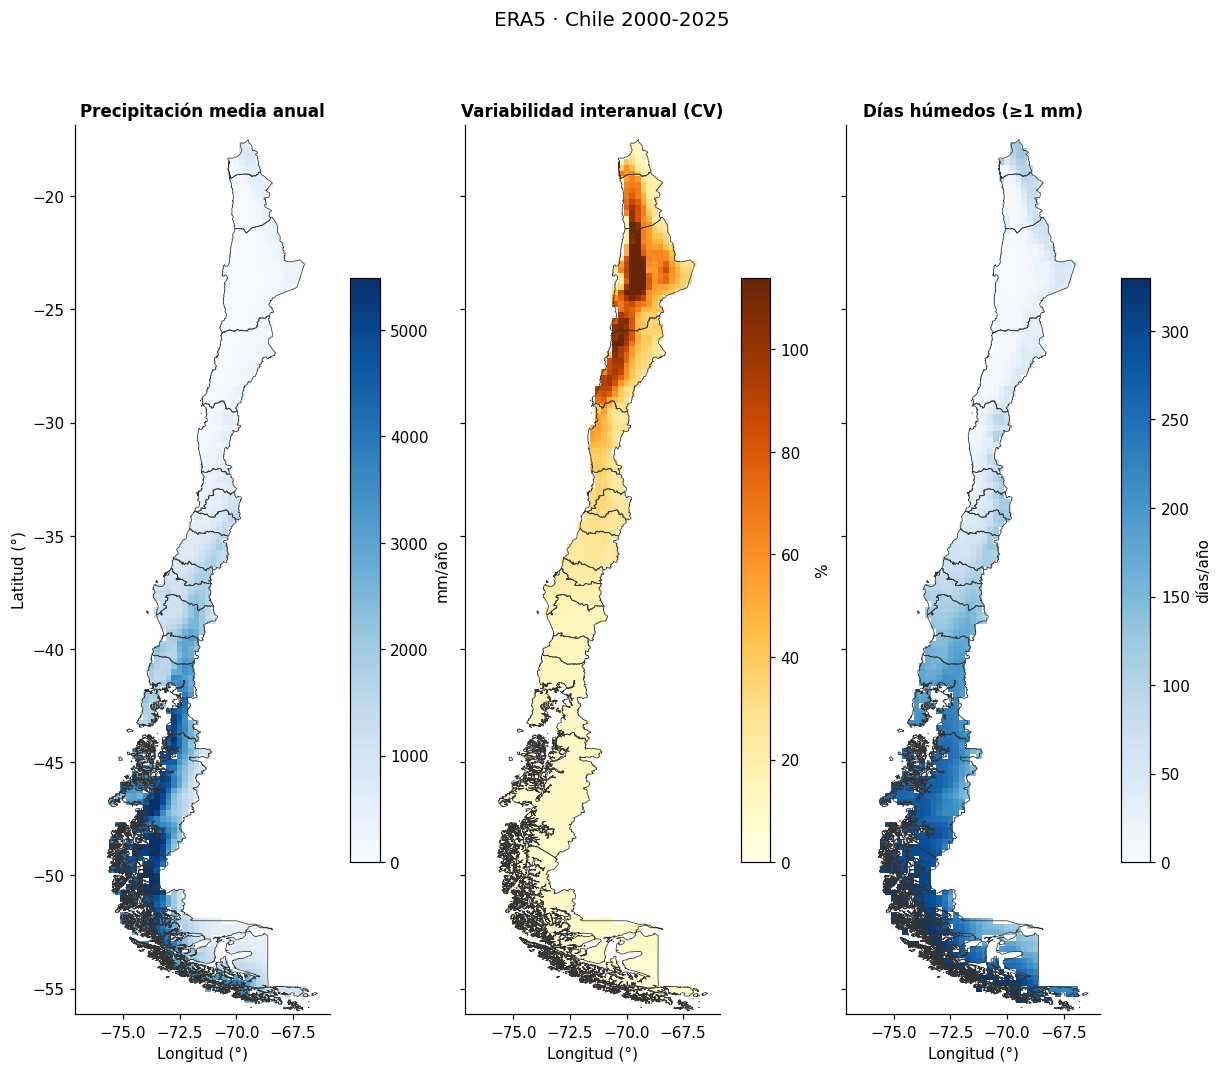

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(11, 10), constrained_layout=True, sharey=True)
mapa(clim.clim_anio, axs[0], 'Blues', 'Precipitación media anual', 'mm/año', 0, p_alto(clim.clim_anio))
mapa(clim.cv_anio, axs[1], 'YlOrBr', 'Variabilidad interanual (CV)', '%', 0, p_alto(clim.cv_anio))
mapa(anual.r1mm.mean('time'), axs[2], 'Blues', f'Días húmedos (≥{UMBRAL_DIA_HUMEDO:g} mm)', 'días/año', 0)
axs[0].set_ylabel('Latitud (°)')
fig.suptitle(f'ERA5 · Chile {ANIO_INI}-{ANIO_FIN}', fontsize=13)
guardar_figura(fig, '01_mapas_climatologia_anual')
plt.show()

### 9.2 Climatología estacional

Totales medios por estación con una misma escala de color para comparar (DJF = dic-ene-feb, etc.).

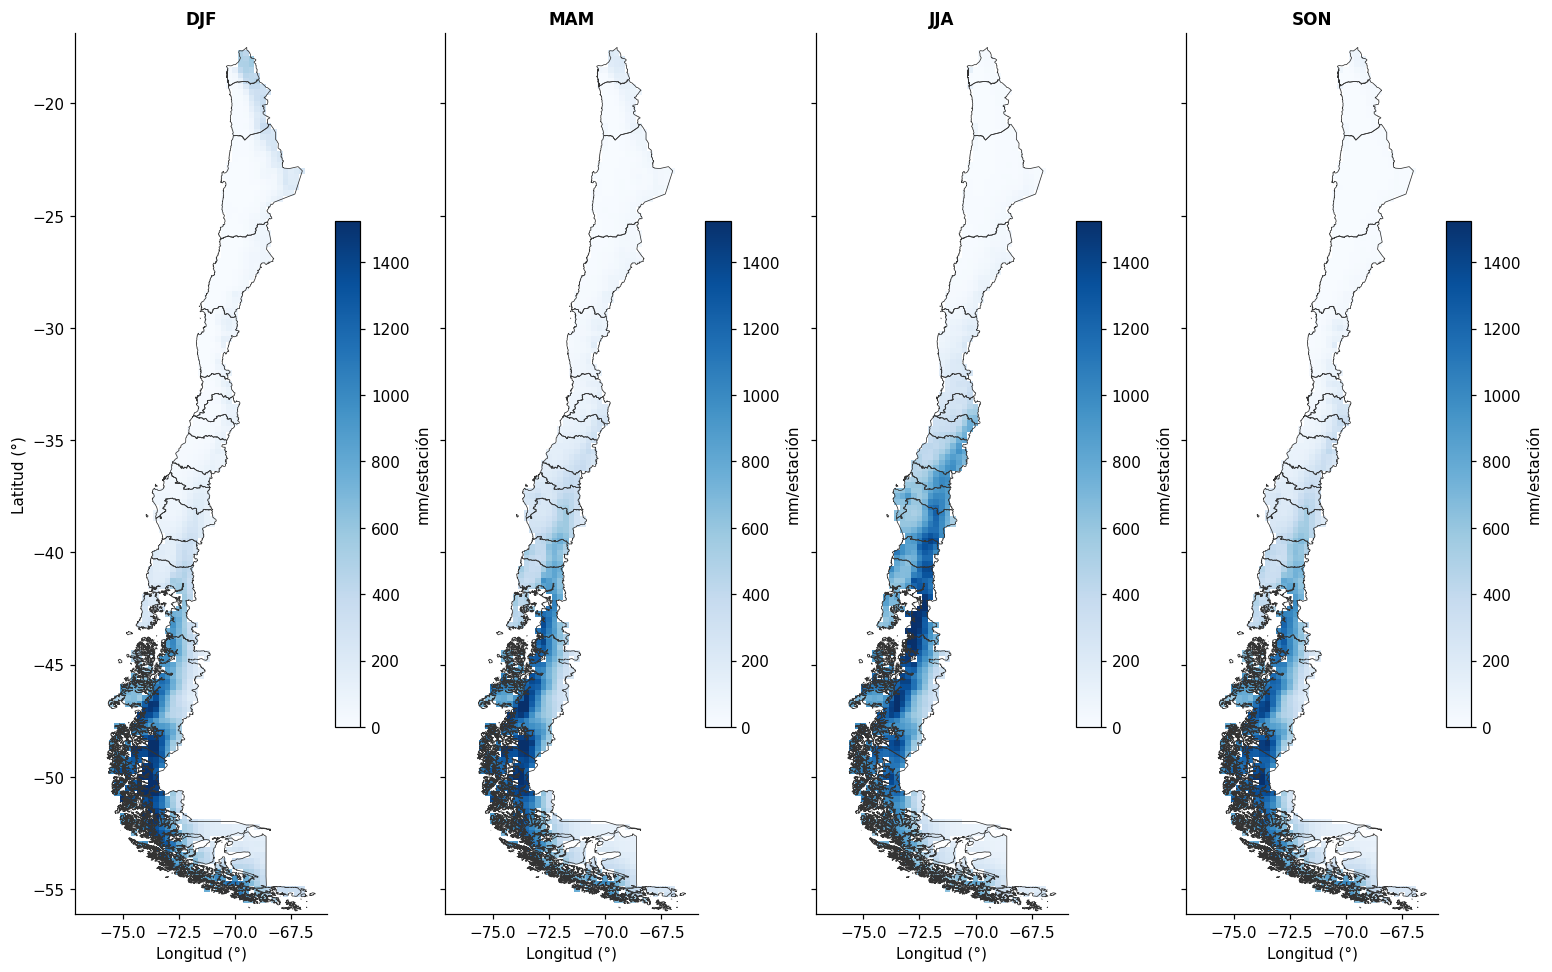

In [21]:
vmax_est = p_alto(clim.clim_est, 99)
fig, axs = plt.subplots(1, 4, figsize=(14, 9), constrained_layout=True, sharey=True)
for ax, est_ in zip(axs, ORDEN_ESTACIONES):
    mapa(clim.clim_est.sel(estacion=est_), ax, 'Blues', est_, 'mm/estación', 0, vmax_est)
axs[0].set_ylabel('Latitud (°)')
guardar_figura(fig, '02_mapas_climatologia_estacional')
plt.show()

### 9.3 Ciclo anual por zona

Media mensual 2000-2025 con ±1 desviación estándar interanual (línea fina). Cada zona con su propio eje Y: las magnitudes difieren en más de un orden entre el norte y el sur.

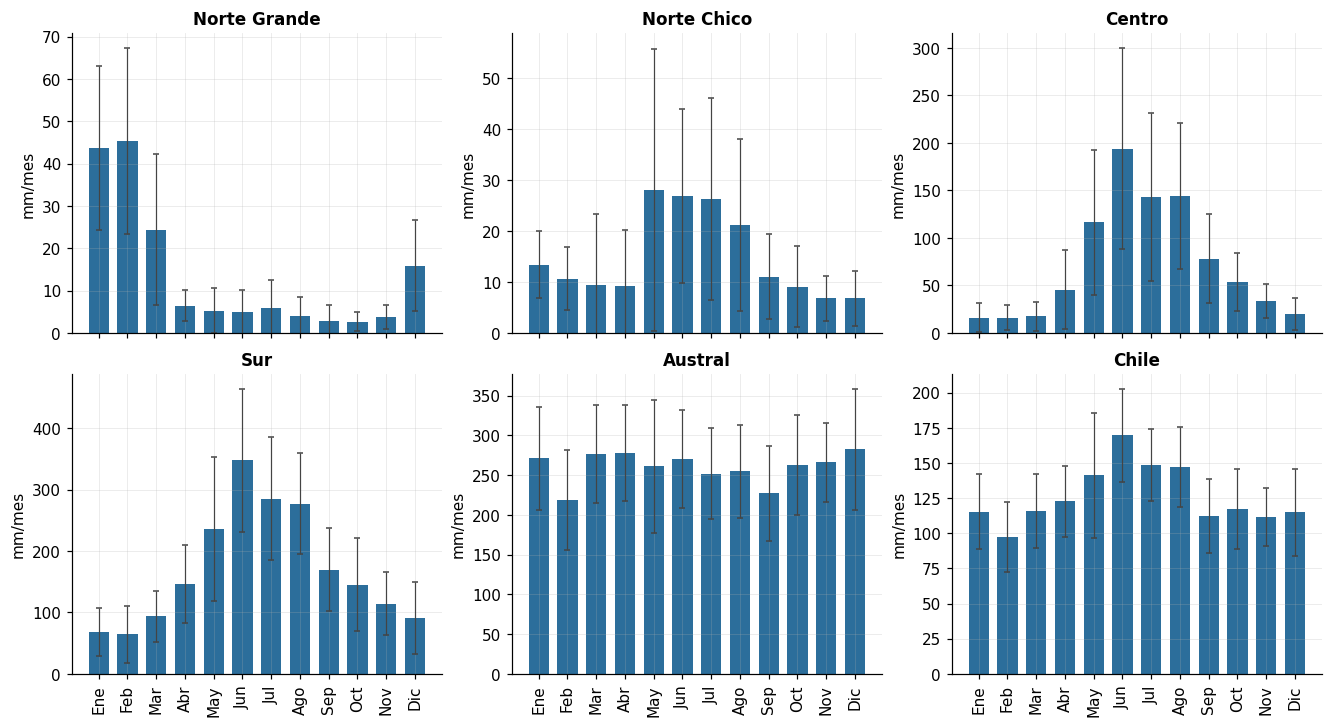

In [22]:
zonas_plot = list(ZONAS) + [NOMBRE_TOTAL]
fig, axs = plt.subplots(2, 3, figsize=(12, 6.5), constrained_layout=True, sharex=True)
for ax, z in zip(axs.flat, zonas_plot):
    serie = z_mes_s.sel(zona=z)
    m = serie.groupby('time.month').mean('time')
    s = serie.groupby('time.month').std('time')
    ax.bar(np.arange(1, 13), m, color=COLOR_BARRA, width=0.7)
    ax.errorbar(np.arange(1, 13), m, yerr=s, fmt='none', ecolor=COLOR_TEXTO, elinewidth=0.8, capsize=2)
    ax.set_title(z)
    ax.set_ylabel('mm/mes')
    ax.set_xticks(np.arange(1, 13), NOMBRES_MES, rotation=90)
    ax.set_ylim(bottom=0)
guardar_figura(fig, '03_ciclo_anual_zonas')
plt.show()

### 9.4 Anomalía anual estandarizada por zona

z-score del total anual respecto de la media 2000-2025 (mismo eje para todas las zonas, por eso son comparables).
Verde-azulado = año más húmedo que lo normal; marrón = más seco.

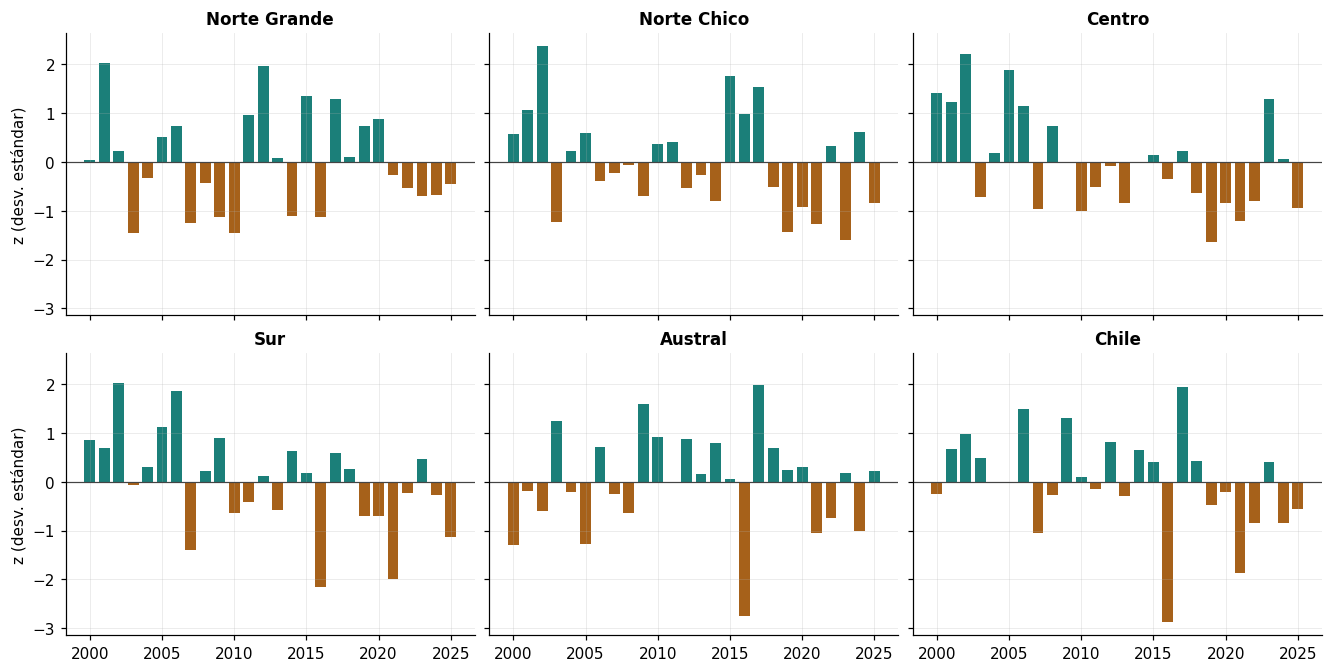

In [23]:
z_zonas = (z_anio_s - z_anio_s.mean('time')) / z_anio_s.std('time')
anios = z_anio_s.time.dt.year.values
fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)
for ax, z in zip(axs.flat, zonas_plot):
    v = z_zonas.sel(zona=z).values
    ax.bar(anios, v, color=np.where(v >= 0, COLOR_POS, COLOR_NEG), width=0.75)
    ax.axhline(0, color=COLOR_TEXTO, lw=0.8)
    ax.set_title(z)
for ax in axs[:, 0]:
    ax.set_ylabel('z (desv. estándar)')
guardar_figura(fig, '04_anomalia_anual_zonas')
plt.show()

### 9.5 Anomalías mensuales año × mes

Anomalía porcentual respecto de la climatología de cada mes en la zona `ZONA_HEATMAP` (parámetro). Permite ver de un vistazo años secos/húmedos y en qué meses ocurrieron.

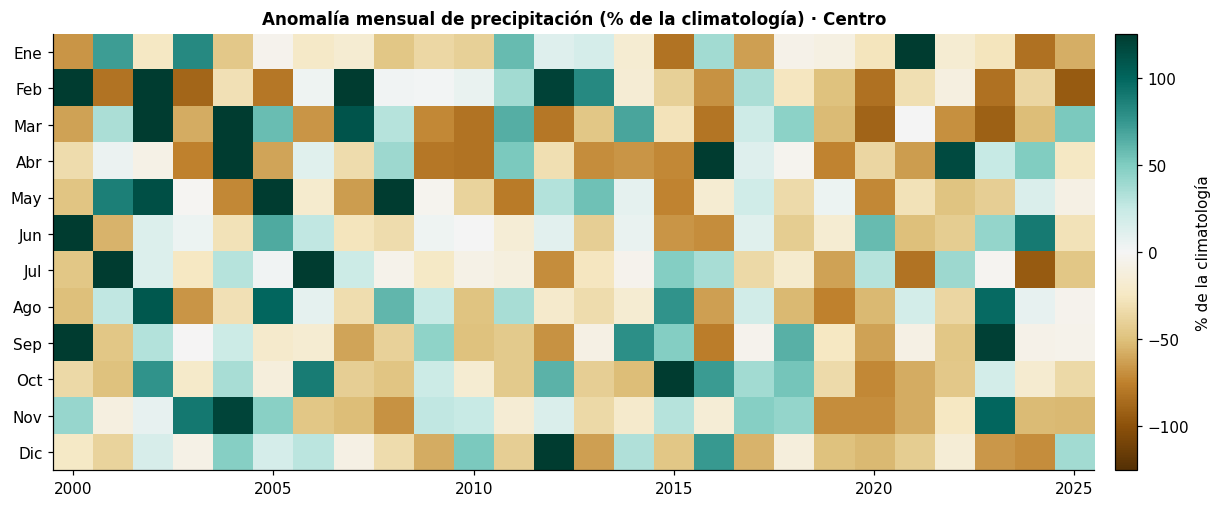

In [24]:
serie = z_mes_s.sel(zona=ZONA_HEATMAP)
clim_z = serie.groupby('time.month').mean('time')
pct = 100 * ((serie.groupby('time.month') - clim_z).groupby('time.month') / clim_z.where(clim_z >= CLIM_MINIMA_PCT))

tabla = pd.Series(pct.values, index=pd.MultiIndex.from_arrays([serie.time.dt.year.values, serie.time.dt.month.values])).unstack()
tabla = tabla.reindex(columns=range(1, 13))
lim = float(np.nanpercentile(np.abs(tabla.values), 95))

fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
im = ax.imshow(tabla.T.values, aspect='auto', cmap='BrBG', vmin=-lim, vmax=lim, origin='upper',
               extent=[tabla.index.min() - 0.5, tabla.index.max() + 0.5, 12.5, 0.5])
ax.set_yticks(range(1, 13), NOMBRES_MES)
ax.grid(False)
ax.set_title(f'Anomalía mensual de precipitación (% de la climatología) · {ZONA_HEATMAP}')
plt.colorbar(im, ax=ax, pad=0.02, label='% de la climatología')
guardar_figura(fig, '05_heatmap_anomalias_mensuales')
plt.show()

### 9.6 Climogramas de ciudades

Ciclo anual medio de la celda ERA5 más cercana. En el título, el total anual medio y las coordenadas reales de la celda usada.

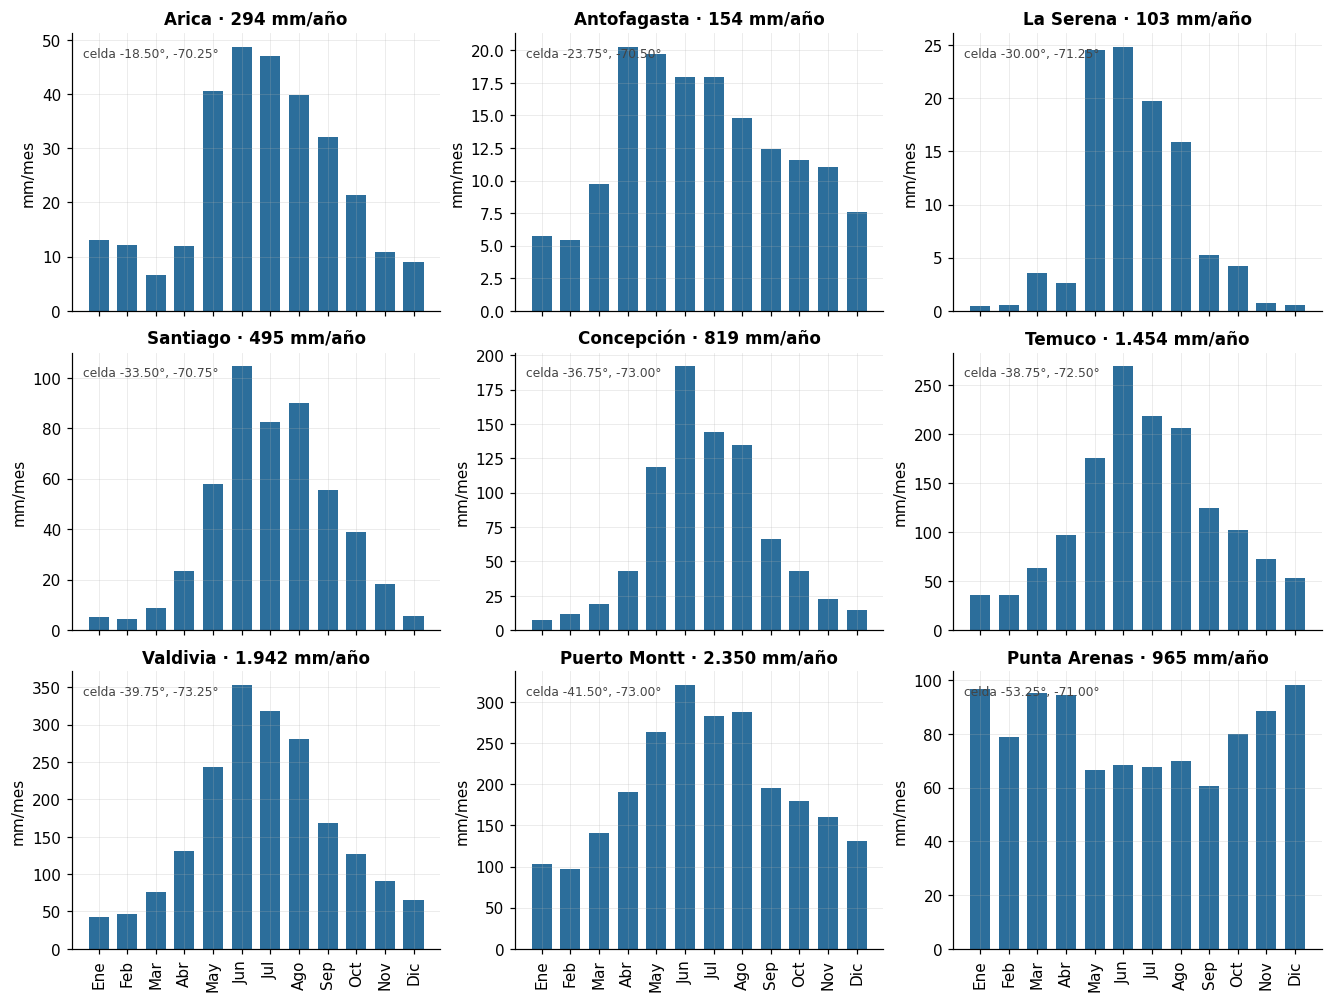

In [25]:
fig, axs = plt.subplots(3, 3, figsize=(12, 9), constrained_layout=True, sharex=True)
for ax, ciudad in zip(axs.flat, CIUDADES):
    s = c_mes_s.sel(ciudad=ciudad)
    m = s.groupby('time.month').mean('time')
    ax.bar(np.arange(1, 13), m, color=COLOR_BARRA, width=0.7)
    total = float(c_anio_s.sel(ciudad=ciudad).mean('time'))
    ax.set_title(f'{ciudad} · {total:,.0f} mm/año'.replace(',', '.'))
    ax.set_xticks(np.arange(1, 13), NOMBRES_MES, rotation=90)
    ax.set_ylabel('mm/mes')
    ax.text(0.03, 0.95, f'celda {float(s.latitude):.2f}°, {float(s.longitude):.2f}°', transform=ax.transAxes,
            ha='left', va='top', fontsize=8, color=COLOR_TEXTO)
guardar_figura(fig, '06_climogramas_ciudades')
plt.show()

### 9.7 Índices de extremos (media 2000-2025)

Promedio anual de los índices de la sección 4 para cada celda.

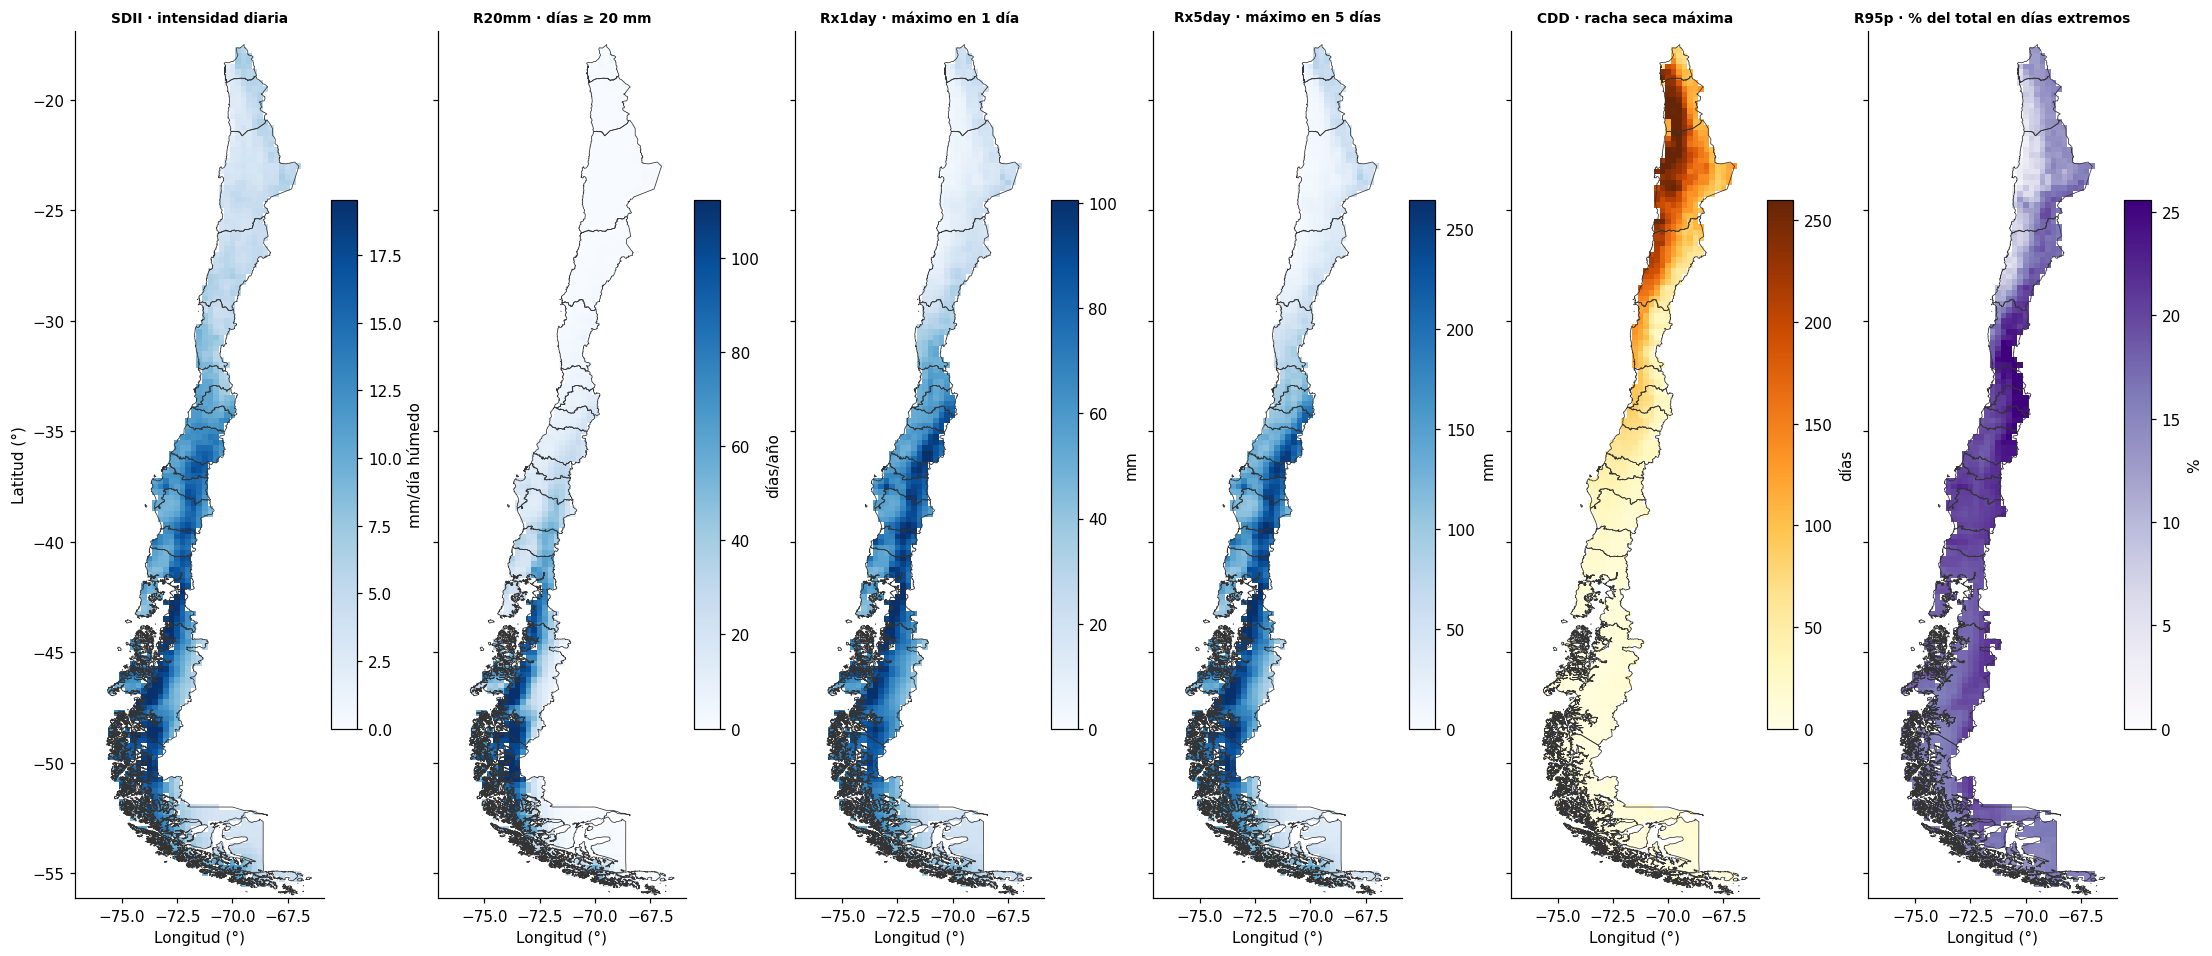

In [26]:
indices = [
    ('sdii', 'SDII · intensidad diaria', 'mm/día húmedo', 'Blues'),
    ('r20mm', f'R20mm · días ≥ {UMBRAL_R20:g} mm', 'días/año', 'Blues'),
    ('rx1day', 'Rx1day · máximo en 1 día', 'mm', 'Blues'),
    ('rx5day', 'Rx5day · máximo en 5 días', 'mm', 'Blues'),
    ('cdd', 'CDD · racha seca máxima', 'días', 'YlOrBr'),
    ('r95p_pct', 'R95p · % del total en días extremos', '%', 'Purples'),
]
fig, axs = plt.subplots(1, 6, figsize=(20, 9), constrained_layout=True, sharey=True)
for ax, (v, titulo, unidad, cmap) in zip(axs, indices):
    d = anual[v].mean('time')
    mapa(d, ax, cmap, titulo, unidad, 0, p_alto(d))
    ax.title.set_fontsize(9)
axs[0].set_ylabel('Latitud (°)')
guardar_figura(fig, '07_mapas_indices_extremos')
plt.show()

### 9.8 Serie diaria en una celda

Precipitación diaria 2000-2025 de la celda ERA5 más cercana a la ciudad elegida en `CIUDAD_SERIE` 

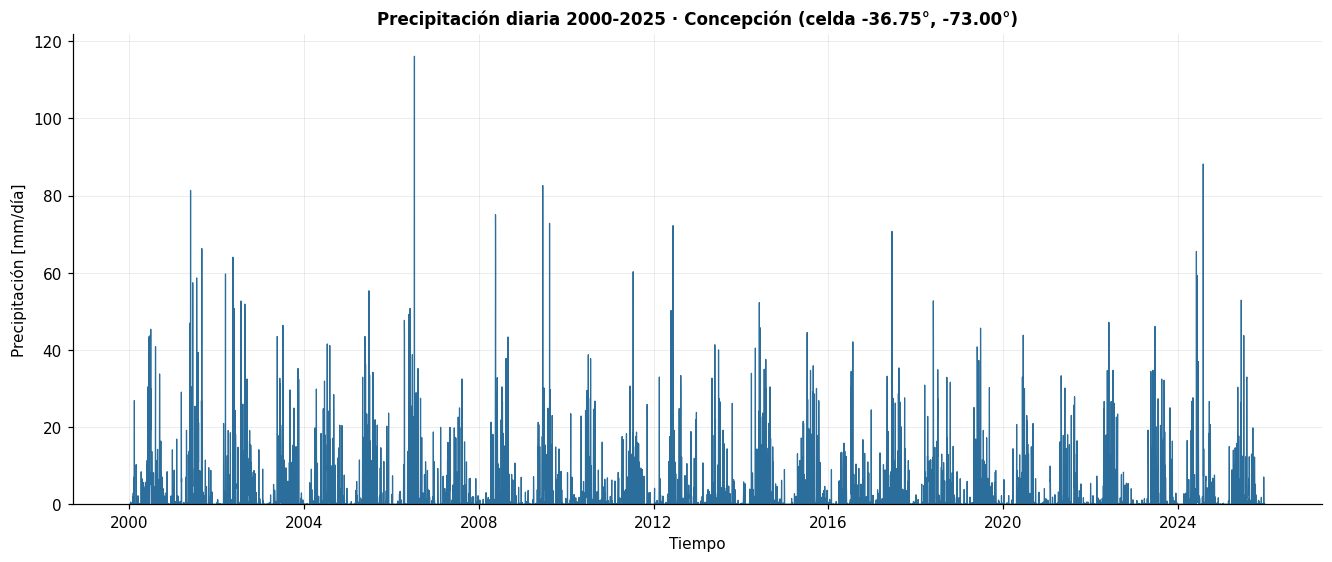

In [ ]:
CIUDAD_SERIE = 'Concepción'   

serie_dia = tp_raw.sel(latitude=CIUDADES[CIUDAD_SERIE][0], longitude=CIUDADES[CIUDAD_SERIE][1], method='nearest').compute()

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.plot(serie_dia.time, serie_dia, color=COLOR_BARRA, linewidth=0.8)
ax.set_title(f'Precipitación diaria {ANIO_INI}-{ANIO_FIN} · {CIUDAD_SERIE} '
             f'(celda {float(serie_dia.latitude):.2f}°, {float(serie_dia.longitude):.2f}°)')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Precipitación [mm/día]')
ax.set_ylim(bottom=0)
guardar_figura(fig, '09_serie_diaria_ciudad')
plt.show()

## 10. Tendencias

Tendencia lineal (mínimos cuadrados) del total anual, expresada en **mm por década**, con valor p de dos colas de la pendiente (t de Student, n−2 grados de libertad).
Se usa `xarray.cov` y `xarray.corr`, sin bucles por celda. Docs: [`xarray.cov`](https://docs.xarray.dev/en/stable/generated/xarray.cov.html),
[`scipy.special.stdtr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.stdtr.html).

> Con 26 años y variabilidad interanual alta (ENSO, PDO), pocas celdas tendrán tendencias significativas. Es una primera señal, no una atribución.

c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Javiera\anaconda3\envs\pythongis\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


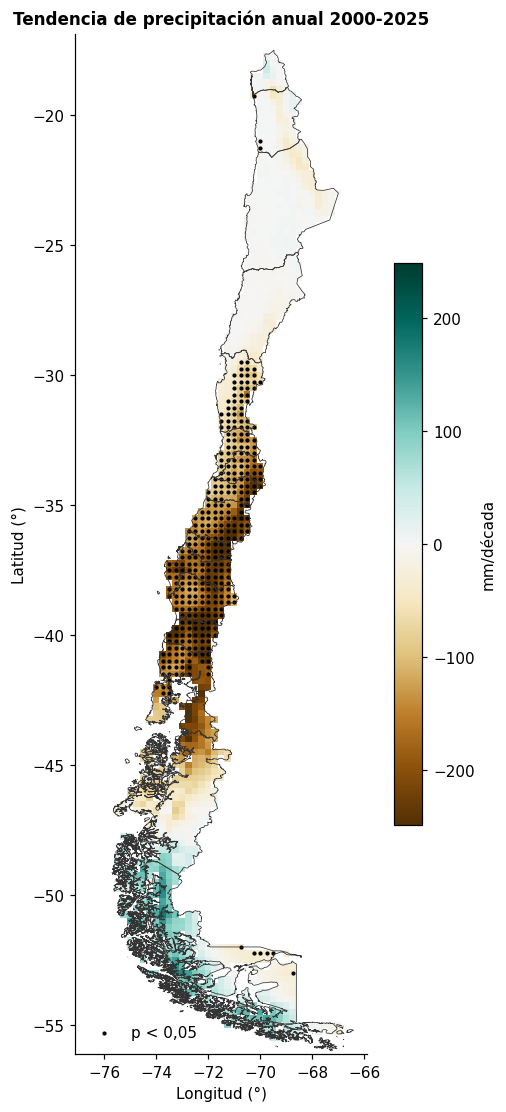

Celdas con tendencia significativa (p<0,05): 347 de 1254 (27.7 %)


In [28]:
def tendencia_lineal(da, dim='time'):
    """Pendiente por década, valor p y n de una regresión lineal contra el año."""
    t = xr.DataArray(da[dim].dt.year.values.astype(float), dims=dim, coords={dim: da[dim]})
    n = da.sizes[dim]
    pendiente = xr.cov(t, da, dim=dim) / t.var(dim, ddof=1)
    r = xr.corr(t, da, dim=dim)
    with np.errstate(divide='ignore', invalid='ignore'):
        t_stat = r * np.sqrt((n - 2) / (1 - r ** 2))
        p = 2 * xr.apply_ufunc(stdtr, n - 2, -np.abs(t_stat))
    return (pendiente * 10).rename('pendiente_mm_decada'), p.rename('p_valor')


pend, pval = tendencia_lineal(anual.tp_anio)
lim = float(np.nanpercentile(np.abs(pend.values), 98))

fig, ax = plt.subplots(figsize=(5.5, 10), constrained_layout=True)
mapa(pend, ax, 'BrBG', f'Tendencia de precipitación anual {ANIO_INI}-{ANIO_FIN}', 'mm/década', -lim, lim)
sig = (pval < 0.05) & pend.notnull()
yy, xx = np.meshgrid(pend.latitude.values, pend.longitude.values, indexing='ij')
ax.scatter(xx[sig.values], yy[sig.values], s=3, color='k', label='p < 0,05')
ax.legend(loc='lower left', frameon=False)
ax.set_ylabel('Latitud (°)')
guardar_figura(fig, '08_tendencia_anual')
plt.show()
print(f'Celdas con tendencia significativa (p<0,05): {int(sig.sum())} de {int(pend.notnull().sum())} '
      f'({100 * int(sig.sum()) / int(pend.notnull().sum()):.1f} %)')

## 11. Taabla resumen y exportación a CSV

Resumen por zona con: media y variabilidad anual, tendencia (mm/década y % de la media por década con su valor p), participación del invierno (JJA) en el total, y años extremos.
Las series agregadas se exportan a CSV (UTF-8 con BOM, abre bien en Excel).

In [29]:
pend_z, pval_z = tendencia_lineal(z_anio_s)
media_z, std_z = z_anio_s.mean('time'), z_anio_s.std('time')
est_medias = z_est_s.groupby('estacion').mean('time')
anio_num = z_anio_s.time.dt.year.values

resumen = pd.DataFrame({
    'media_anual_mm': media_z.to_series(),
    'desv_est_mm': std_z.to_series(),
    'cv_pct': (100 * std_z / media_z).to_series(),
    'tendencia_mm_decada': pend_z.to_series(),
    'tendencia_pct_decada': (100 * pend_z / media_z).to_series(),
    'p_valor': pval_z.to_series(),
    'pct_invierno_JJA': (100 * est_medias.sel(estacion='JJA') / est_medias.sum('estacion')).to_series(),
    'anio_mas_humedo': pd.Series(anio_num[z_anio_s.argmax('time').values], index=z_anio_s.zona.values),
    'anio_mas_seco': pd.Series(anio_num[z_anio_s.argmin('time').values], index=z_anio_s.zona.values),
}).loc[zonas_plot].round(2)
resumen.index.name = 'zona'
resumen

,media_anual_mm,desv_est_mm,cv_pct,tendencia_mm_decada,tendencia_pct_decada,p_valor,pct_invierno_JJA,anio_mas_humedo,anio_mas_seco
zona,,,,,,,,,
Norte Grande,164.860001,45.130001,27.370001,-5.10,-3.10,0.68,9.000000,2001,2010
Norte Chico,178.610001,54.290001,30.389999,-25.12,-14.06,0.08,41.509998,2002,2023
Centro,876.940002,211.089996,24.070000,-147.08,-16.77,0.01,54.939999,2002,2019
Sur,2038.380005,278.089996,13.640000,-190.91,-9.37,0.01,44.759998,2002,2016
Austral,3119.500000,247.250000,7.930000,1.17,0.04,0.99,24.900000,2017,2016
Chile,1514.140015,113.830002,7.520000,-50.38,-3.33,0.10,30.770000,2017,2016


In [30]:
for nombre, serie_ in series.items():
    serie_.to_pandas().to_csv(DIR_SALIDA / f'{nombre}.csv', encoding='utf-8-sig', float_format='%.3f')
resumen.to_csv(DIR_SALIDA / 'resumen_zonas.csv', encoding='utf-8-sig')

print('Archivos en', DIR_SALIDA)
for f in sorted(DIR_SALIDA.glob('*.*')):
    print(f'  {f.name:32s} {f.stat().st_size / 1e6:8.2f} MB')

Archivos en D:\Documents\Proyectos\era5\agregados_tp
  ciudades_anual.csv                   0.00 MB
  ciudades_mensual.csv                 0.02 MB
  resumen_zonas.csv                    0.00 MB
  tp_anual.nc                          1.62 MB
  tp_climatologias.nc                  0.24 MB
  tp_estacional.nc                     1.24 MB
  tp_hidrologico.nc                    0.31 MB
  tp_mensual.nc                        9.70 MB
  zonas_anual.csv                      0.00 MB
  zonas_estacional.csv                 0.01 MB
  zonas_hidrologico.csv                0.00 MB
  zonas_mensual.csv                    0.02 MB


### Cerrar el cluster

In [31]:
client.close()
print('Cluster cerrado.')

Cluster cerrado.
